# 序列还没写完，显存怎么分？Paged Attention

前面几章我们一直在优化注意力**怎么算**。这一章彻底换个赛道：优化 KV cache **在显存里怎么摆**。

问题是这样的：推理时 KV cache 随生成逐 token 变长，可你**事先根本不知道**一个请求最终会生成多长。
传统做法只能按"模型支持的最大长度"给每个请求预留一大块连续显存——结果就是大量空预留、显存碎片、
能并发的请求数被卡死。

vLLM 的解法很优雅：**把操作系统的虚拟内存分页搬过来**。这一章我们就把这套机制——分页、block table、
间接寻址——一步步搭出来。kernel 提取自 lightllm（一个把"间接寻址"表达得极清楚的 163 行实现）。


In [1]:
import sys, math
from pathlib import Path

import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "05-paged-attention"))

from common import naive_attention
from paged import PagedKVCache, paged_decode_attention

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0), "| 本章 kernel 提取自 lightllm")

# 中文正常显示 + 暗色代码高亮（适配深色编辑器），见 common/nbtools.py
from common.nbtools import setup_cjk, show_code
setup_cjk()


跑在 NVIDIA GeForce RTX 4090 | 本章 kernel 提取自 lightllm


'Noto Sans SC'

## 先看浪费：按最大长度预留有多亏

假设模型支持 8192 的上下文，来了 8 个请求，但它们实际只生成了几百到一两千个 token。
传统方案给每个请求都预留 8192 的空间：


In [2]:
seqlens = torch.randint(128, 2048, (8,), generator=torch.Generator().manual_seed(0)).tolist()
max_len = 8192

print("8 个请求的实际长度：", seqlens)
print(f"\n传统预分配：每个按 max_len={max_len} 预留 → 共 {8*max_len:>6} 个 token 的空间")
print(f"实际用到　：　　　　　　　　　　　　　　 {sum(seqlens):>6} 个 token")
print(f"浪费率：{(1 - sum(seqlens)/(8*max_len))*100:.0f}%  ← 九成多的预留显存是空的")


8 个请求的实际长度： [172, 1967, 1141, 1088, 1731, 1787, 195, 231]

传统预分配：每个按 max_len=8192 预留 → 共  65536 个 token 的空间
实际用到　：　　　　　　　　　　　　　　   8312 个 token
浪费率：87%  ← 九成多的预留显存是空的


## 抄操作系统的作业：分页 + block table

操作系统早就解决过一模一样的难题——你写程序时不必预知要用多少内存，OS 用**分页**按需给你。
paged attention 照搬：

1. 把 KV cache 切成固定大小的物理 **block（页）**，丢进一个统一的池子；
2. 每个序列维护一张 **block table**：记录"我的 token 存在哪些物理 block"；
3. 需要新空间了，就从池子里取一个空闲 block——**按需分配**，序列在物理上**不必连续**。

`PagedKVCache` 就是这套机制的最小实现。我们给一个序列喂 10 个 token，看它怎么分配 block
（block_size=4，所以 10 个 token 要 3 个 block）：


In [3]:
cache = PagedKVCache(num_blocks=32, block_size=4, num_kv_heads=2, head_dim=64)
for t in range(10):
    kt = torch.randn(2, 64, dtype=torch.float16, device="cuda")
    cache.append(req_id=0, k_tok=kt, v_tok=kt)

print("序列 0 的长度　　　:", cache.length[0])
print("序列 0 的 block table:", cache.block_table[0], " ← 占用的物理 block 编号")
print("逻辑位置 → 物理 slot :", {p: cache._slot(0, p) for p in [0, 3, 4, 9]})
print("  （逻辑第 4 个 token 落到了第 2 个 block 的开头——block table 完成了这层翻译）")


序列 0 的长度　　　: 10
序列 0 的 block table: [0, 1, 2]  ← 占用的物理 block 编号
逻辑位置 → 物理 slot : {0: 0, 3: 3, 4: 4, 9: 9}
  （逻辑第 4 个 token 落到了第 2 个 block 的开头——block table 完成了这层翻译）


## 注意力照算，只多一次"查表"

paged 的注意力计算和普通注意力**没有任何区别**，还是 QK^T·softmax·V。唯一的不同是：
KV 散落在物理池各处，读之前先用 block table 把逻辑位置翻译成物理 slot。kernel 里就是这两步
（原样来自 lightllm）：


In [4]:
src = (ROOT / "05-paged-attention" / "paged_decode_triton.py").read_text().splitlines()
i = next(idx for idx, l in enumerate(src) if "Req_to_tokens + cur_batch_req_idx" in l)
print("# --- paged_decode_triton.py 的间接寻址（kernel 的灵魂）---")
for l in src[i-1:i+8]:
    print("   " + l.rstrip())
print("\n# Req_to_tokens[req, 逻辑位置] = 物理 slot；再用物理 slot 去读 K/V。")


# --- paged_decode_triton.py 的间接寻址（kernel 的灵魂）---
           kv_loc = tl.load(
               Req_to_tokens + cur_batch_req_idx * stride_req_to_tokens_b + start_n + offs_n,
               mask=(start_n + offs_n) < cur_batch_seq_len,
               other=0,
           ).to(tl.int64)
           k = tl.load(
               k_ptrs + kv_loc[None, :] * stride_kbs, mask=(start_n + offs_n[None, :]) < cur_batch_seq_len, other=0.0
           )
   

# Req_to_tokens[req, 逻辑位置] = 物理 slot；再用物理 slot 去读 K/V。


## 直接读这个 kernel

把整个 kernel 摊开来读（提取自 lightllm，带语法高亮）——它只有一百多行，灵魂就是那次"查表"：


In [5]:
from IPython.display import Code
show_code(str(ROOT / "05-paged-attention" / "paged_decode_triton.py"))


### 逐段读懂它

**① 每个 program 服务一个序列 × 一个 KV 头（连同共享它的那组 query 头）**

```python
cur_batch = tl.program_id(0); cur_kv_head = tl.program_id(1)
cur_q_head_range = cur_kv_head * kv_group_num + cur_q_head_offs   # 这一组 query 头
q = tl.load(Q + off_q, ...)    # decode：每序列只有 1 个新 token，载入它的这组 query 头
```

decode 时每个序列只有 1 个 query token，所以没有 query 块循环；一个 program 负责一个序列的一个
KV 头（GQA 下它服务一组 query 头）。

**② 灵魂：间接寻址，逻辑位置 → 物理 slot**

```python
kv_loc = tl.load(Req_to_tokens + cur_batch_req_idx * stride_b + start_n + offs_n)  # 查 block table
k = tl.load(k_ptrs + kv_loc[None, :] * stride_kbs, ...)    # 用物理 slot 去读 K
```

这是整个 paged 的核心：先查 `Req_to_tokens` 把逻辑位置翻译成物理 slot，再拿 slot 去显存里读 KV。
物理上散落、乱序都没关系。

**③ online softmax（flash-decoding 风格）**

```python
m_ij = tl.maximum(m_i, tl.max(qk, 1));  p = tl.exp(qk - m_ij[:, None])
alpha = tl.exp(m_i - m_i_new); ...        # 边扫边修正，和 01 章一样
```

扫描这个序列的全部历史 KV，用 online softmax 增量更新——又是那套熟悉的 running max/sum/output。

**④ V 走同一个 kv_loc，加权累加后写回**

```python
v = tl.load(v_ptrs + kv_loc[:, None] * stride_vbs, ...)   # V 也用同一个物理 slot
acc += tl.dot(p, v)
```

V 同样用 `kv_loc` 间接读出、加权累加。注意力的算术毫无变化——全部精髓只在那次"查表寻址"。


## 验证：物理 slot 乱序，结果照样对

正因为有 block table 这层间接，物理布局哪怕**完全乱序**也不影响结果。我们装 3 个不同长度的序列，
做一步 decode，和"把 KV 当连续张量"的朴素参考对一对：


In [6]:
Hq, Hkv, D = 8, 2, 64
seqlens = [300, 500, 128]
cache = PagedKVCache(1024, block_size=16, num_kv_heads=Hkv, head_dim=D)
ks, vs = [], []
for r, L in enumerate(seqlens):
    k_seq = torch.randn(L, Hkv, D, dtype=torch.float16, device="cuda")
    v_seq = torch.randn(L, Hkv, D, dtype=torch.float16, device="cuda")
    for t in range(L):
        cache.append(r, k_seq[t], v_seq[t])
    ks.append(k_seq); vs.append(v_seq)

q = torch.randn(len(seqlens), Hq, D, dtype=torch.float16, device="cuda")
out = paged_decode_attention(q, cache, list(range(len(seqlens))))

for r, L in enumerate(seqlens):
    q4 = q[r].unsqueeze(0).unsqueeze(2)
    k4 = ks[r].permute(1, 0, 2).unsqueeze(0)
    v4 = vs[r].permute(1, 0, 2).unsqueeze(0)
    ref = naive_attention(q4, k4, v4, causal=False)[0, :, 0, :]
    print(f"序列 {r} (len={L}): 与朴素参考最大差异 {(out[r]-ref).abs().max().item():.1e}  ✓")


序列 0 (len=300): 与朴素参考最大差异 1.2e-04  ✓
序列 1 (len=500): 与朴素参考最大差异 1.2e-04  ✓
序列 2 (len=128): 与朴素参考最大差异 2.4e-04  ✓


## 真实推理：多序列交错生成，物理 block 自然交错

真实场景里很多请求**同时**在生成，每步给每个活跃序列各加一个 token。于是它们的物理 block
会交替分配、彼此交错——但只要 block table 记着账，寻址永远不会乱：


In [7]:
seqlens = [6, 9, 5]
cache = PagedKVCache(64, block_size=4, num_kv_heads=2, head_dim=64)
ks = [torch.randn(L, 2, 64, dtype=torch.float16, device="cuda") for L in seqlens]
vs = [torch.randn(L, 2, 64, dtype=torch.float16, device="cuda") for L in seqlens]

# 交替 append：每个"时间步"给所有还在生成的序列各加一个 token
for t in range(max(seqlens)):
    for r, L in enumerate(seqlens):
        if t < L:
            cache.append(r, ks[r][t], vs[r][t])

for r in range(len(seqlens)):
    print(f"序列 {r} 的 block table: {cache.block_table[r]}")
print("  ↑ 编号交错，说明三条序列的 block 在物理池里是交替分配的（不连续）。")

q = torch.randn(len(seqlens), 8, 64, dtype=torch.float16, device="cuda")
out = paged_decode_attention(q, cache, list(range(len(seqlens))))
errs = []
for r, L in enumerate(seqlens):
    ref = naive_attention(q[r].unsqueeze(0).unsqueeze(2),
                          ks[r].permute(1,0,2).unsqueeze(0),
                          vs[r].permute(1,0,2).unsqueeze(0), causal=False)[0,:,0,:]
    errs.append((out[r]-ref).abs().max().item())
print(f"交错分配下，3 条序列最大差异都 < {max(errs):.0e}  ✓ 寻址完全正确")


序列 0 的 block table: [0, 3]
序列 1 的 block table: [1, 4, 6]
序列 2 的 block table: [2, 5]
  ↑ 编号交错，说明三条序列的 block 在物理池里是交替分配的（不连续）。
交错分配下，3 条序列最大差异都 < 1e-03  ✓ 寻址完全正确


## 省了多少？利用率几乎拉满

回到最初的浪费问题。64 个长度参差的请求，传统按 max_len 预留 vs paged 按需分配：


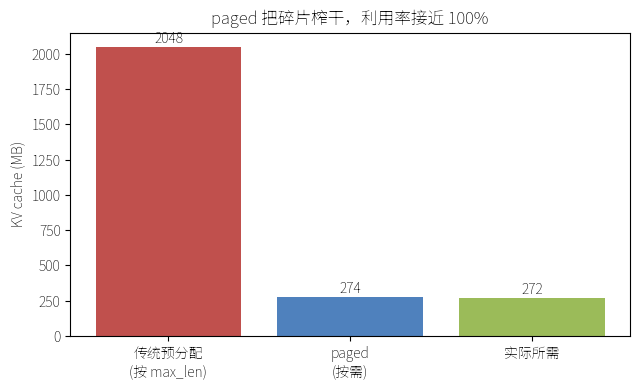

paged 比传统省 7×，利用率 99%——同样的显存能多跑好几倍的请求。


In [8]:
Hkv, D, block_size, max_len = 8, 128, 16, 8192
seqlens = torch.randint(128, 2048, (64,), generator=torch.Generator().manual_seed(0)).tolist()
bpt = 2 * Hkv * D * 2  # 每 token 的 K+V 字节数

trad   = 64 * max_len * bpt / 1024**2
paged  = sum(((L + block_size - 1)//block_size)*block_size for L in seqlens) * bpt / 1024**2
actual = sum(seqlens) * bpt / 1024**2

plt.figure(figsize=(6.5, 4))
bars = plt.bar(["传统预分配\n(按 max_len)", "paged\n(按需)", "实际所需"],
               [trad, paged, actual], color=["#c0504d", "#4f81bd", "#9bbb59"])
plt.ylabel("KV cache (MB)"); plt.title("paged 把碎片榨干，利用率接近 100%")
for b, val in zip(bars, [trad, paged, actual]):
    plt.text(b.get_x()+b.get_width()/2, val, f"{val:.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"paged 比传统省 {trad/paged:.0f}×，利用率 {actual/paged*100:.0f}%——同样的显存能多跑好几倍的请求。")


## 收尾

- paged attention 优化的不是"怎么算"，而是 **KV cache 怎么在显存里摆**；
- 它照搬操作系统的**分页 + block table**：固定大小 block 按需分配，序列物理上可不连续；
- 注意力计算照旧，只多一次"逻辑位置→物理 slot"的**间接寻址**——物理乱序、交错都不影响正确性；
- 收益是**显存利用率接近 100%**（实测省 7×），这正是 vLLM 能高并发、高吞吐的基石。

到这里**基础线（01–05）就走完了**：从 vanilla → FlashAttention → GQA → 滑动窗口 → paged，
覆盖了现代 LLM 注意力在训练与推理两侧的主干。再往后是稀疏注意力（NSA/DSA）与线性注意力
（GLA/DeltaNet/KDA）两条更前沿的路线。
